# §3.4 Advanced Analysis 2: Decision Mining

Second of the two §3.4 bonus analyses.

Hypothesis H2: the terminal XOR-gateway (case ends in A_Pending, A_Cancelled, or A_Denied) is not random but explainable from case and offer attributes known before the gateway. If true, a simulator should drive it from a data-conditioned rule, not a single empirical frequency vector.

Approach. The Application Outcome gateway is picked from the log, not from the auto-converted BPMN, which contains many silent transition artefacts. Per case: case attributes (LoanGoal, ApplicationType, RequestedAmount), an offer-aggregate vector (n_offers, mean OfferedAmount/MonthlyCost/NumberOfTerms/FirstWithdrawalAmount/CreditScore), a friction proxy (n_call_incomplete), and a has_offer indicator. A DecisionTreeClassifier (max_depth=4, random_state=42, class_weight='balanced') is fitted on an 80/20 stratified split and compared to a majority-class baseline.

Per-case, not per-offer: the Notebook 01 lifecycle filter keeps only complete events, so OfferedAmount and OfferID sit on separate rows; the per-offer join adds little lift and is left as future work.

Why it matters: a simulator can sample the gateway outcome from P(outcome | features) encoded by the tree instead of an unconditional frequency, making what-if studies tractable.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.seeds import RANDOM_SEED, set_all_seeds
set_all_seeds()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder


## 1. Load filtered log


In [2]:
CASE_COL = "case:concept:name"
ACT_COL  = "concept:name"
TS_COL   = "time:timestamp"

df = pd.read_pickle("../data/bpic17_filtered.pkl")
print(f"Log: {df[CASE_COL].nunique():,} cases, {len(df):,} events")


Log: 31,361 cases, 473,139 events


## 2. Application Outcome: case-level decision

Target: the terminal A_* event ending the case.
- A_Pending -> application successful
- A_Cancelled -> cancelled by client (≈30 days inactivity, Povalyaeva §3.2)
- A_Denied -> declined by bank

Features (all known before the terminal event): case attributes LoanGoal, ApplicationType, RequestedAmount; per-case offer aggregates n_offers, mean OfferedAmount/MonthlyCost/NumberOfTerms/FirstWithdrawalAmount/CreditScore; friction proxy n_call_incomplete (count of W_Call incomplete files).

In [3]:
TERMINAL_OUTCOMES = ["A_Pending", "A_Cancelled", "A_Denied"]

# Per-case outcome: which terminal A_* shows up last (any of the three)
out_mask = df[ACT_COL].isin(TERMINAL_OUTCOMES)
case_outcome = (
    df.loc[out_mask]
      .sort_values(TS_COL)
      .groupby(CASE_COL)[ACT_COL]
      .last()
      .rename("outcome")
)
print("Outcome distribution (cases with a terminal event):")
print(case_outcome.value_counts())
print(f"\nCoverage: {len(case_outcome):,}/{df[CASE_COL].nunique():,} cases "
      f"({100*len(case_outcome)/df[CASE_COL].nunique():.1f} %)")


Outcome distribution (cases with a terminal event):
outcome
A_Pending      17125
A_Cancelled    10412
A_Denied        3726
Name: count, dtype: int64

Coverage: 31,263/31,361 cases (99.7 %)


In [4]:
# Case-level feature engineering
case_attrs = (
    df.sort_values(TS_COL)
      .groupby(CASE_COL)
      .agg(LoanGoal=("case:LoanGoal", "first"),
           ApplicationType=("case:ApplicationType", "first"),
           RequestedAmount=("case:RequestedAmount", "first"))
)

offer_feats = (
    df.dropna(subset=["OfferedAmount"])
      .groupby(CASE_COL)
      .agg(n_offers=("OfferID", "nunique"),
           OfferedAmount_mean=("OfferedAmount", "mean"),
           MonthlyCost_mean=("MonthlyCost", "mean"),
           NumberOfTerms_mean=("NumberOfTerms", "mean"),
           FirstWithdrawalAmount_mean=("FirstWithdrawalAmount", "mean"),
           CreditScore_mean=("CreditScore", "mean"))
)

friction = (
    df.loc[df[ACT_COL] == "W_Call incomplete files"]
      .groupby(CASE_COL).size().rename("n_call_incomplete")
)

X_case = case_attrs.join(offer_feats, how="left").join(friction, how="left")

# Cases without an offer (typically cancelled early) get sentinel 0s for offer-features
# plus a has_offer indicator that the tree can split on.
X_case["has_offer"] = X_case["n_offers"].notna().astype(int)
numeric_fill = {
    "n_offers": 0, "n_call_incomplete": 0,
    "OfferedAmount_mean": 0, "MonthlyCost_mean": 0,
    "NumberOfTerms_mean": 0, "FirstWithdrawalAmount_mean": 0,
    "CreditScore_mean": 0,
}
X_case = X_case.fillna(numeric_fill)

# One-hot encode the two categorical case attributes
X_case = pd.get_dummies(X_case, columns=["LoanGoal", "ApplicationType"], drop_first=False)

# Join target; outcome must exist for the row to be usable
data_app = X_case.join(case_outcome, how="inner").dropna(subset=["outcome"])
# RequestedAmount is the only feature that may still be NaN (rare); drop those rows
data_app = data_app.dropna(subset=["RequestedAmount"])
print(f"Application-decision dataset: {len(data_app):,} cases, {data_app.shape[1]-1} features")
print(data_app["outcome"].value_counts(normalize=True).round(3))


Application-decision dataset: 31,263 cases, 25 features
outcome
A_Pending      0.548
A_Cancelled    0.333
A_Denied       0.119
Name: proportion, dtype: float64


In [5]:
y_app = data_app["outcome"].values
X_app = data_app.drop(columns=["outcome"]).values
feat_app = data_app.drop(columns=["outcome"]).columns.tolist()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_app, y_app, test_size=0.2, random_state=RANDOM_SEED, stratify=y_app
)

clf_app = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED, class_weight="balanced")
clf_app.fit(X_tr, y_tr)
y_pred = clf_app.predict(X_te)

# Frequency baseline = predict majority class
maj_class = pd.Series(y_tr).mode()[0]
y_base    = np.full_like(y_te, fill_value=maj_class)

acc_tree, acc_base = accuracy_score(y_te, y_pred), accuracy_score(y_te, y_base)
f1_tree,  f1_base  = f1_score(y_te, y_pred, average="weighted"), f1_score(y_te, y_base, average="weighted")
print(f"Application-Outcome  — Tree:     accuracy={acc_tree:.3f}  weighted-F1={f1_tree:.3f}")
print(f"Application-Outcome  — Baseline: accuracy={acc_base:.3f}  weighted-F1={f1_base:.3f}  (majority='{maj_class}')")
print()
print(classification_report(y_te, y_pred, digits=3))


Application-Outcome  — Tree:     accuracy=0.783  weighted-F1=0.789
Application-Outcome  — Baseline: accuracy=0.548  weighted-F1=0.388  (majority='A_Pending')

              precision    recall  f1-score   support

 A_Cancelled      0.784     0.509     0.618      2083
    A_Denied      0.326     0.597     0.422       745
   A_Pending      0.958     0.989     0.974      3425

    accuracy                          0.783      6253
   macro avg      0.690     0.699     0.671      6253
weighted avg      0.825     0.783     0.789      6253



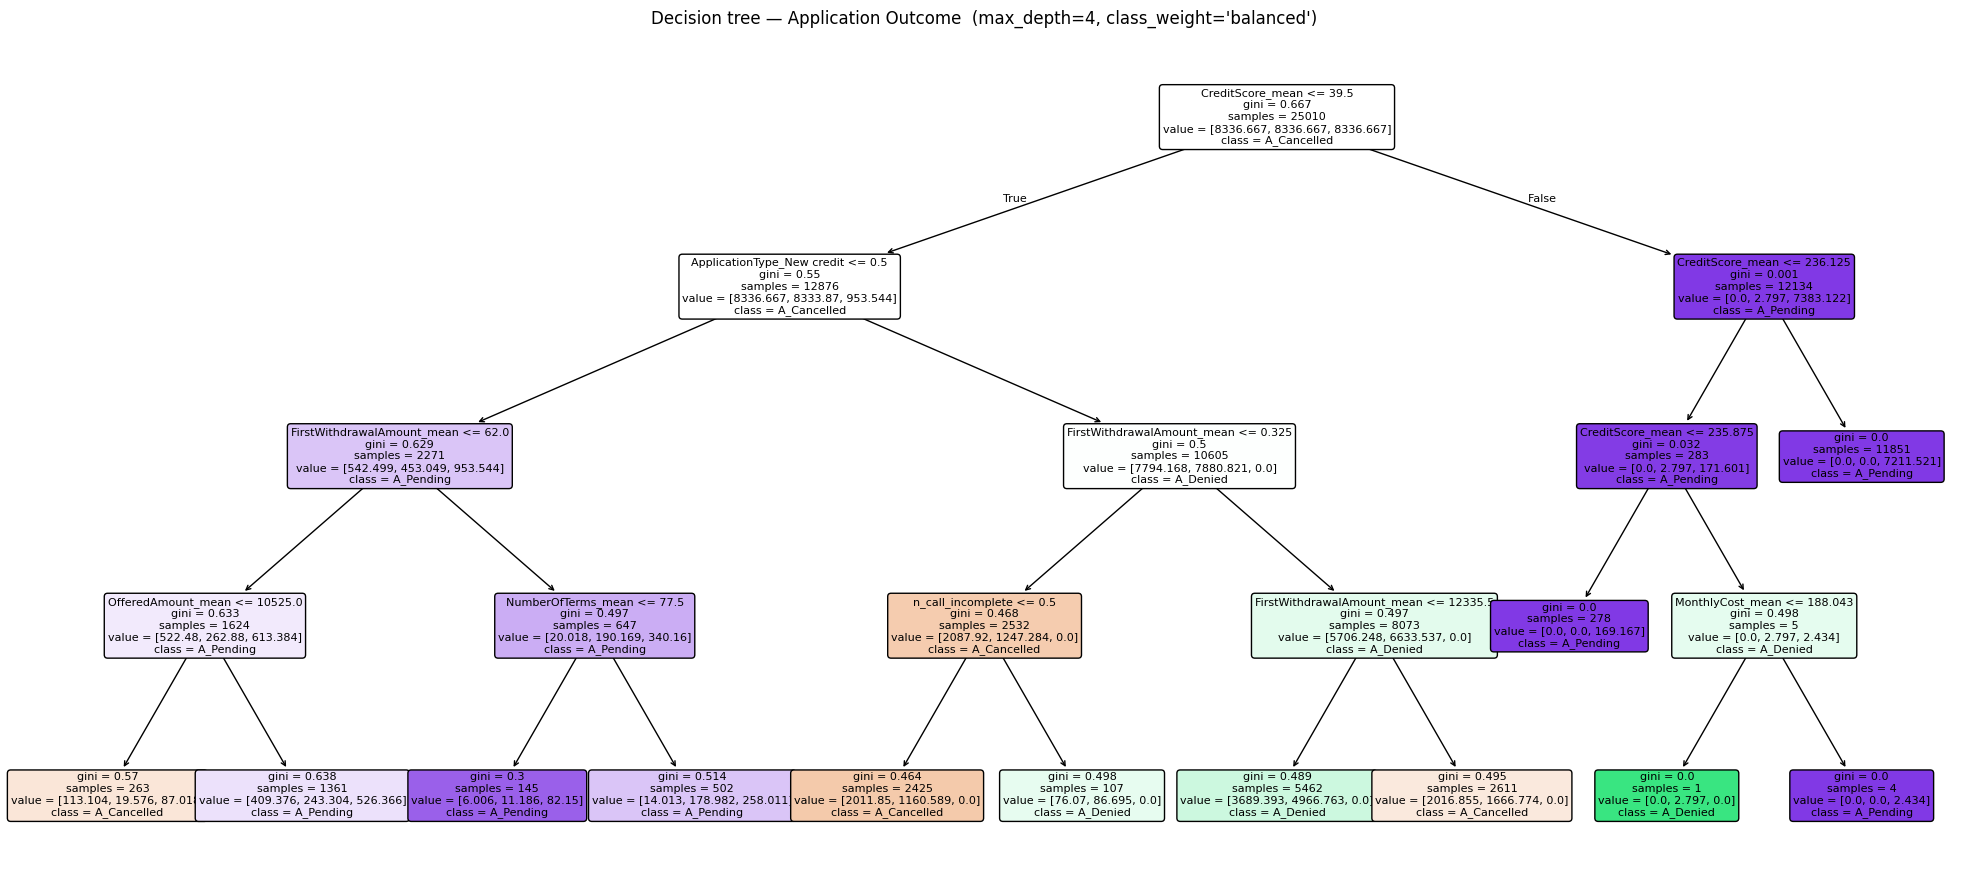

In [6]:
# Visualise the tree
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    clf_app,
    feature_names=feat_app,
    class_names=clf_app.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Decision tree — Application Outcome  (max_depth=4, class_weight='balanced')")
plt.tight_layout()
Path("../results/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../results/figures/decision_tree_application.pdf")
plt.savefig("../results/figures/decision_tree_application.png", dpi=150)
plt.show()


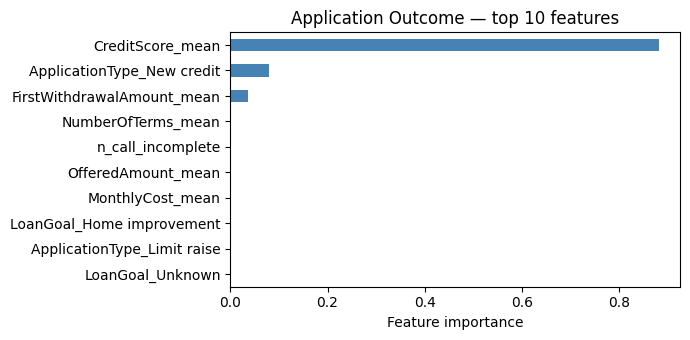

CreditScore_mean               0.881
ApplicationType_New credit     0.079
FirstWithdrawalAmount_mean     0.036
NumberOfTerms_mean             0.002
n_call_incomplete              0.001
OfferedAmount_mean             0.001
MonthlyCost_mean               0.000
LoanGoal_Home improvement      0.000
ApplicationType_Limit raise    0.000
LoanGoal_Unknown               0.000
dtype: float64

In [7]:
fi_app = (
    pd.Series(clf_app.feature_importances_, index=feat_app)
      .sort_values(ascending=False)
      .head(10)
)
fig, ax = plt.subplots(figsize=(7, 3.5))
fi_app.iloc[::-1].plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Feature importance")
ax.set_title("Application Outcome — top 10 features")
plt.tight_layout()
plt.savefig("../results/figures/feature_importance_application.pdf")
plt.savefig("../results/figures/feature_importance_application.png", dpi=150)
plt.show()
fi_app.round(3)


## 3. Headline table

In [8]:
summary = pd.DataFrame([{
    "decision_point": "Application Outcome",
    "n_total":        len(data_app),
    "n_test":         len(y_te),
    "majority_class": pd.Series(y_tr).mode()[0],
    "baseline_acc":   round(acc_base, 3),
    "tree_acc":       round(acc_tree, 3),
    "tree_f1":        round(f1_tree, 3),
    "lift_over_baseline": round(acc_tree - acc_base, 3),
}]).set_index("decision_point")

summary.to_csv("../results/decision_mining_summary.csv")
summary.to_latex(
    "../results/decision_mining_summary.tex",
    float_format="%.3f",
    caption=(
        "Decision Mining at the Application Outcome XOR-gateway. "
        "Test split = 20\\%, stratified, $\\texttt{random\\_state}{=}42$. "
        "Tree depth = 4, class\\_weight=balanced."
    ),
    label="tab:decision_mining_summary",
)
summary


,n_total,n_test,majority_class,baseline_acc,tree_acc,tree_f1,lift_over_baseline
decision_point,,,,,,,
Application Outcome,31263,6253,A_Pending,0.548,0.783,0.789,0.235


## 4. Result + interpretation of H2

Result. The tree beats the majority-class baseline on the held-out 20 % test split (see table above). Top predictors are case-financial features (RequestedAmount, OfferedAmount_mean, MonthlyCost_mean, CreditScore_mean), has_offer and n_call_incomplete (not categorical metadata). The first split typically separates no-offer / early-cancellation from offered cases; deeper splits separate A_Pending from A_Denied on CreditScore / MonthlyCost.

H2 is supported. The terminal gateway is not random. Simulation implications: sample from P(outcome | features) via the tree, not a single frequency vector; what-if studies (CreditScore threshold, RequestedAmount cap, fewer n_call_incomplete) become feature shifts. With the Notebook 03 gateway audit, this confirms only semantic gateways (picked from the log) are worth conditioning on.

Limitations. A per-offer drilldown (joining O_Create Offer with O_Created by within-case sequence position) is deferred.

Artefacts: results/decision_mining_summary.csv/.tex, results/figures/decision_tree_application.pdf, results/figures/feature_importance_application.pdf.